In [1]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

import sys
sys.path.append("../utils/")
import format_stim_data
import scipy.io
import os

import itertools

In [6]:
bird_id = 'ROS134'
save_folder = f"../figures/antidromic_hpc_to_lhy/{bird_id}/"

ML = np.arange(0.2, 1.6, 0.2)
AP = np.arange(3.0, 5.0, 0.2)
ML_grid, AP_grid = np.meshgrid(ML, AP)

print(f'ML coords: {ML}')
print(f'AP coords: {AP}')

ML coords: [0.2 0.4 0.6 0.8 1.  1.2 1.4]
AP coords: [3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6 4.8]


In [4]:
hits = [(5, 1),  
        (4, 2), (5, 2),
        (4, 3),
        (3, 4),
        (2, 5),
        (1, 6), (2, 6),
        (1, 7),
        (0, 8), (1, 8)
       ]

weak = [(4, 1),
        (2, 4),
        (1, 9)
       ]

no_response = [
    (6, 0), 
    (6, 1),
    (3, 2), (6, 2),
    (3, 3), (5, 3),
    (4, 4),
    (1, 5), (3, 5),
    (0, 6), (3, 6),
    (0, 7), (2, 7),
    (2, 8),
    (0, 9)
]

In [21]:
# ML, AP
HPC_edge = [
    (3.9, 0.78),
    (3.8, 0.85),
    (3.7, 0.95),
    (3.6, 0.95),
    (3.5, 1.2),
    (3.4, 1.2),
    (3.3, 1.3)
]

HPC_edge_AP = np.arange(3.3, 3.9, 0.1)
HPC_edge_ML = np.asarray([1.3, 1.2, 1.2, 0.95, 0.95, 0.85, 0.78])

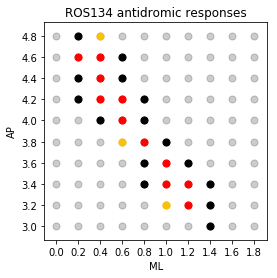

In [7]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))

ML_plus = np.arange(0, 2, 0.2)
for ml in ML_plus:
    for ap in AP:
        ax.scatter(ml, ap,
                   c='k', s=50, 
                   alpha=0.2, zorder=0)

for h in hits:
    ml, ap = h
    ax.scatter(ML[ml], AP[ap],
               c='r', s=50, 
               alpha=1, zorder=1)

for w in weak:
    ml, ap = w
    ax.scatter(ML[ml], AP[ap],
               c='xkcd:goldenrod', 
               s=50, alpha=1, zorder=1)
    
for n in no_response:
    ml, ap = n
    ax.scatter(ML[ml], AP[ap],
               c='k', s=50, 
               alpha=1, zorder=1)

ax.set_xticks(np.round(ML_plus, 1))
# ax.set_xticks(np.round(ML, 1))
ax.set_yticks(np.round(AP, 1))

ax.set_title(f'{bird_id} antidromic responses')
ax.set_xlabel('ML')
ax.set_ylabel('AP')

f.savefig(f'{save_folder}{bird_id}_response_grid.png', dpi=600, bbox_inches='tight')
plt.show()

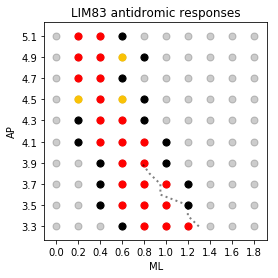

In [25]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))

ML_plus = np.arange(0, 2, 0.2)
for ml in ML_plus:
    for ap in AP:
        ax.scatter(ml, ap,
                   c='k', s=50, 
                   alpha=0.2, zorder=0)

for h in hits:
    ml, ap = h
    ax.scatter(ML[ml], AP[ap],
               c='r', s=50, 
               alpha=1, zorder=1)

for w in weak:
    ml, ap = w
    ax.scatter(ML[ml], AP[ap],
               c='xkcd:goldenrod', 
               s=50, alpha=1, zorder=1)
    
for n in no_response:
    ml, ap = n
    ax.scatter(ML[ml], AP[ap],
               c='k', s=50, 
               alpha=1, zorder=1)
    
ax.plot(HPC_edge_ML, HPC_edge_AP, 
        ':k', lw=2,
        alpha=0.5, zorder=2)

ax.set_xticks(np.round(ML_plus, 1))
# ax.set_xticks(np.round(ML, 1))
ax.set_yticks(np.round(AP, 1))

ax.set_title(f'{bird_id} antidromic responses')
ax.set_xlabel('ML')
ax.set_ylabel('AP')

f.savefig(f'{save_folder}{bird_id}_response_grid_HPC.png', dpi=600, bbox_inches='tight')
plt.show()